# Pengujian NutriFit — Prapemrosesan, Penetapan Klaster, dan Rekomendasi CBF

Notebook ini menjalankan **pipeline yang sama persis dengan aplikasi**, bukan
salinannya. Setiap angka di bawah berasal dari fungsi di `src/recommender.py`
yang benar-benar dipanggil saat pengguna memakai NutriFit — kalau kodenya
berubah, notebook ini ikut berubah, dan tidak mungkin melaporkan hasil yang
sudah tidak berlaku.

Isinya tiga bagian:

| Bagian | Menjawab |
| --- | --- |
| 1. Prapemrosesan | Data apa yang masuk, apa yang disaring, dan mengapa |
| 2. Penetapan klaster | Apakah datanya layak diklasterkan, berapa klaster yang dipakai, dan apa isinya |
| 3. Pengujian rekomendasi CBF | Seberapa tepat peringkat Content-Based Filtering menu dan latihan |

**Yang tidak ada di sini:** metrik mutu klaster sesudah K ditetapkan — Silhouette,
Calinski-Harabasz, dan Rasio Hamming. Bagian klaster menunjukkan kelayakan data,
hasil pengelompokan, dan isinya; penilaian mutu bukan tujuan notebook ini.

## 0. Persiapan

In [1]:
# Notebook ini TIDAK butuh paket kmodes. K-Modes dan K-Prototypes yang dipakai
# adalah implementasi milik aplikasi sendiri (src/recommender.py) -- menguji
# library pihak ketiga berarti menguji kode yang tidak pernah dijalankan produk.
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():          # kalau notebook dibuka dari folder induk
    ROOT = ROOT / "NutriFit"
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from src import recommender as R
from src import ranking_metrics as RM
from src.nutrition import classify_bmi

plt.rcParams["figure.figsize"] = (7, 4)
pd.set_option("display.width", 140)
print("Modul aplikasi diimpor dari:", ROOT)

Modul aplikasi diimpor dari: C:\Kuliah\Semester 8\Tugas Akhir\Coding\NutriFit


---

## 1. Prapemrosesan Data

Tiga dataset masuk ke sistem, dan ketiganya melewati pembersihan sebelum
diklaster. Bagian ini menunjukkan berapa baris yang tersaring dan atas dasar apa.

### 1.1 Sumber data

In [2]:
DATA = ROOT / "data"

# Sumber utama: tabel yang benar-benar dibaca aplikasi.
try:
    anggota_mentah, makanan_mentah, latihan_mentah = R.load_dataset_tables()
    SUMBER = "Basis data (sumber yang dipakai aplikasi)"
except Exception as galat:            # mis. dijalankan tanpa akses basis data
    print(f"!! Basis data tidak bisa dihubungi ({type(galat).__name__}), memakai CSV benih.")
    print("!! Angka di bawah menggambarkan CSV, BELUM TENTU sama dengan yang diterima pengguna.")
    anggota_mentah = pd.read_csv(DATA / "gym_members.csv")
    makanan_mentah = pd.read_csv(DATA / "food_nutrition.csv")
    latihan_mentah = pd.read_csv(DATA / "training_program.csv")
    SUMBER = "CSV benih (basis data tidak tersedia)"

print("Sumber data:", SUMBER)
print(f"  Profil anggota  : {len(anggota_mentah):5d} baris x {len(anggota_mentah.columns)} kolom")
print(f"  Menu makanan    : {len(makanan_mentah):5d} baris x {len(makanan_mentah.columns)} kolom")
print(f"  Program latihan : {len(latihan_mentah):5d} baris x {len(latihan_mentah.columns)} kolom")

Sumber data: Basis data (sumber yang dipakai aplikasi)
  Profil anggota  :   973 baris x 17 kolom
  Menu makanan    :  1587 baris x 7 kolom
  Program latihan :  2918 baris x 9 kolom


### 1.2 Menjalankan pipeline aplikasi

Ketiga fungsi di bawah adalah fungsi yang sama yang dipanggil `load_datasets()`
saat aplikasi dijalankan. Tidak ada pembersihan tambahan khusus notebook.

In [3]:
members   = R.clean_members(anggota_mentah)
foods     = R.prepare_foods(makanan_mentah)
exercises = R.prepare_exercises(latihan_mentah)

ringkas = pd.DataFrame([
    {"Dataset": "Profil anggota",  "Baris masuk": len(anggota_mentah), "Dipakai": len(members)},
    {"Dataset": "Menu makanan",    "Baris masuk": len(makanan_mentah), "Dipakai": len(foods)},
    {"Dataset": "Program latihan", "Baris masuk": len(latihan_mentah), "Dipakai": len(exercises)},
])
ringkas["Tersaring"] = ringkas["Baris masuk"] - ringkas["Dipakai"]
ringkas["% tersaring"] = (ringkas["Tersaring"] / ringkas["Baris masuk"] * 100).round(1)
display(ringkas)

,Dataset,Baris masuk,Dipakai,Tersaring,% tersaring
0,Profil anggota,973,973,0,0.0
1,Menu makanan,1587,780,807,50.9
2,Program latihan,2918,1359,1559,53.4


### 1.3 Menu apa yang tersaring, dan atas dasar apa

`filter_recommendable_foods()` membuang entri yang bukan hidangan siap santap.
Aturannya berupa DAFTAR TOLAK, bukan daftar izin: sebuah menu diterima **kecuali**
namanya menunjukkan ia bukan makanan jadi. Tabel di bawah memecah alasannya satu
per satu.

In [4]:
nama_menu = makanan_mentah["name"].fillna("").astype(str).str.lower().str.strip()

alasan = [
    ("Bukan pangan manusia",            R.NOT_HUMAN_FOOD_PATTERN),
    ("Non-halal / satwa dilindungi",    R.PROTECTED_OR_HARAM_DISH_PATTERN),
    ("Protein diawetkan garam",         R.SALT_CURED_PROTEIN_PATTERN),
    ("Bahan, bumbu, olahan setengah jadi", R.INGREDIENT_PATTERN),
    ("Buah sebagai bahan",              R.FRUIT_AS_INGREDIENT_PATTERN),
    ("Dikecualikan (daftar khusus)",    R.EXCLUDED_FOOD_PATTERN),
    ("Bukan satu hidangan utuh",        R.NOT_A_MEAL_PATTERN),
]
baris = []
for label, pola in alasan:
    kena = nama_menu.str.contains(pola, regex=True, na=False)
    contoh = makanan_mentah.loc[kena, "name"].head(3).tolist()
    baris.append({"Alasan penolakan": label, "Baris kena": int(kena.sum()),
                  "Contoh": ", ".join(str(x)[:26] for x in contoh)})

masuk_akal = R.nutrition_is_plausible(makanan_mentah)
baris.append({"Alasan penolakan": "Gizi tidak masuk akal", "Baris kena": int((~masuk_akal).sum()),
              "Contoh": ", ".join(str(x)[:26] for x in makanan_mentah.loc[~masuk_akal, "name"].head(3))})

display(pd.DataFrame(baris))
print(f"\nSatu baris bisa kena lebih dari satu alasan, jadi jumlah kolom tengah")
print(f"melebihi total tersaring. Yang lolos seluruh saringan: {len(foods)} menu.")

,Alasan penolakan,Baris kena,Contoh
0,Bukan pangan manusia,30,"Ampas kacang hijau, Ampas Tahu, Ampas tahu kukus"
1,Non-halal / satwa dilindungi,9,"Ham, Ikan Belida bakar, Ikan Belida segar"
2,Protein diawetkan garam,59,"Buaya daging dendeng menta, Dendeng belut gore..."
3,"Bahan, bumbu, olahan setengah jadi",488,"Akar tonjong segar, Ampas tahu mentah, Andalim..."
4,Buah sebagai bahan,7,"Jantung Pisang segar, Kacang mete/biji jambu m..."
5,Dikecualikan (daftar khusus),20,"Babi daging gemuk segar, Babi daging kurus seg..."
6,Bukan satu hidangan utuh,58,"Andewi, Asam masak di pohon, Baligo"
7,Gizi tidak masuk akal,101,"Agar-agar, Babi hutan masak rica masa, Bawang ..."



Satu baris bisa kena lebih dari satu alasan, jadi jumlah kolom tengah
melebihi total tersaring. Yang lolos seluruh saringan: 780 menu.


### 1.4 Fitur turunan yang dibuat saat prapemrosesan

Prapemrosesan tidak hanya membuang baris; ia juga membangun kolom yang dipakai
tahap berikutnya.

In [5]:
turunan = pd.DataFrame([
    {"Dataset": "Anggota",  "Kolom": "Experience_Label", "Dibuat dari": "Experience_Level (1/2/3) -> Beginner/Intermediate/Expert"},
    {"Dataset": "Anggota",  "Kolom": "Fitness_Goal",     "Dibuat dari": "BMI + Fat_Percentage, ambang Asia-Pasifik"},
    {"Dataset": "Anggota",  "Kolom": "User_Cluster",     "Dibuat dari": "K-Prototypes atas 4 numerik + 4 kategorikal"},
    {"Dataset": "Makanan",  "Kolom": "Food_Cluster",     "Dibuat dari": "K-Means atas 4 makro + kepadatan protein"},
    {"Dataset": "Makanan",  "Kolom": "Food_Category",    "Dibuat dari": "pola nama bahan utama"},
    {"Dataset": "Makanan",  "Kolom": "Is_Snack",         "Dibuat dari": "kelayakan sebagai camilan"},
    {"Dataset": "Makanan",  "Kolom": "CBF_Text",         "Dibuat dari": "nama + makro + klaster + kategori (masukan TF-IDF)"},
    {"Dataset": "Latihan",  "Kolom": "Exercise_Cluster", "Dibuat dari": "K-Modes atas Type/BodyPart/Equipment/Level"},
    {"Dataset": "Latihan",  "Kolom": "CBF_Text",         "Dibuat dari": "judul + deskripsi + atribut + klaster"},
])
display(turunan)

print("Sebaran BMI anggota menurut classify_bmi() yang sama dengan layar aplikasi:")
kategori_bmi = members["BMI"].apply(classify_bmi)
urutan_bmi = ["Kurus", "Normal", "Gemuk", "Obesitas I", "Obesitas II"]
display(pd.crosstab(kategori_bmi, members["Fitness_Goal"]).reindex(urutan_bmi).fillna(0).astype(int))

,Dataset,Kolom,Dibuat dari
0,Anggota,Experience_Label,Experience_Level (1/2/3) -> Beginner/Intermedi...
1,Anggota,Fitness_Goal,"BMI + Fat_Percentage, ambang Asia-Pasifik"
2,Anggota,User_Cluster,K-Prototypes atas 4 numerik + 4 kategorikal
3,Makanan,Food_Cluster,K-Means atas 4 makro + kepadatan protein
4,Makanan,Food_Category,pola nama bahan utama
5,Makanan,Is_Snack,kelayakan sebagai camilan
6,Makanan,CBF_Text,nama + makro + klaster + kategori (masukan TF-...
7,Latihan,Exercise_Cluster,K-Modes atas Type/BodyPart/Equipment/Level
8,Latihan,CBF_Text,judul + deskripsi + atribut + klaster


Sebaran BMI anggota menurut classify_bmi() yang sama dengan layar aplikasi:


Fitness_Goal,Gain Weight,Lose Weight,Maintain Weight
BMI,,,
Kurus,168,0,0
Normal,0,97,135
Gemuk,0,138,0
Obesitas I,0,243,0
Obesitas II,0,192,0


---

## 2. Penetapan Klaster

Tiga algoritma dipakai untuk tiga tipe data yang berbeda:

| Algoritma | Data | Tipe atribut |
| --- | --- | --- |
| K-Prototypes | Profil anggota | Campuran numerik + kategorikal |
| K-Means | Menu makanan | Numerik |
| K-Modes | Program latihan | Kategorikal |

Bagian ini menunjukkan **bagaimana jumlah klaster ditetapkan** dan **apa isi tiap
klaster** — bukan menilai mutunya.

### 2.0 Apakah datanya memang layak diklasterkan?

Sebelum satu pun algoritma dijalankan, ada pertanyaan yang tidak dijawab oleh
metrik mana pun sesudahnya: **apakah data ini memang punya struktur kelompok?**

Silhouette, Calinski-Harabasz, dan Total Cost selalu menghasilkan angka — bahkan
pada data acak murni. **Hopkins Statistic** memeriksa lebih dulu apakah ada yang
pantas dicari, dengan membandingkan jarak titik ASLI ke tetangga terdekatnya
melawan jarak titik BUATAN acak ke titik asli terdekat.

| Nilai | Artinya |
| --- | --- |
| mendekati 1 | data sangat berkelompok, layak diklasterkan |
| sekitar 0,5 | sebarannya tidak berbeda dari acak seragam |
| mendekati 0 | data tersebar sangat merata, justru anti-kelompok |

Tiap tipe data diperiksa dengan jarak yang benar untuk tipenya: Euclid untuk
numerik, matching dissimilarity untuk kategorikal, dan gabungan keduanya untuk
campuran.

In [6]:
from src import clustering_metrics as CM

numerik_awal, kategorikal_awal, _ = R.member_feature_matrices(
    members, R.MEMBER_NUMERIC_COLUMNS, R.MEMBER_CATEGORICAL_COLUMNS
)
X_menu_awal = R.food_cluster_features(foods)
kategorikal_latihan = R.exercise_cluster_features(exercises).astype(str).to_numpy()

hopkins = pd.DataFrame([
    {"Data": "Profil anggota (campuran)", "Algoritma": "K-Prototypes",
     "Hopkins": round(CM.hopkins_mixed(numerik_awal, kategorikal_awal), 4)},
    {"Data": "Profil anggota (numerik saja)", "Algoritma": "—",
     "Hopkins": round(CM.hopkins_numeric(numerik_awal), 4)},
    {"Data": "Menu makanan (numerik)", "Algoritma": "K-Means",
     "Hopkins": round(CM.hopkins_numeric(X_menu_awal), 4)},
    {"Data": "Program latihan (kategorikal)", "Algoritma": "K-Modes",
     "Hopkins": round(CM.hopkins_categorical(kategorikal_latihan), 4)},
])
hopkins["Tafsir"] = hopkins["Hopkins"].apply(CM.interpret_hopkins)
display(hopkins)

,Data,Algoritma,Hopkins,Tafsir
0,Profil anggota (campuran),K-Prototypes,0.9725,Sangat layak diklasterkan (struktur kelompok k...
1,Profil anggota (numerik saja),—,0.8167,Sangat layak diklasterkan (struktur kelompok k...
2,Menu makanan (numerik),K-Means,0.9455,Sangat layak diklasterkan (struktur kelompok k...
3,Program latihan (kategorikal),K-Modes,0.9721,Sangat layak diklasterkan (struktur kelompok k...


> **Satu catatan kejujuran tentang angka kategorikal.** Hopkins pada data
> kategorikal cenderung tinggi karena titik buatannya dirakit dengan mengambil
> tiap atribut secara acak dan bebas satu sama lain, sehingga sering menghasilkan
> kombinasi yang memang tidak pernah ada di dunia nyata. Nilai tingginya
> menunjukkan bahwa atribut-atributnya saling bergantung — dan itu memang bentuk
> struktur — tetapi jangan dibaca sebagai bukti kelompok yang terpisah rapi.

---

### 2.1 K-Prototypes — profil anggota

Jumlah klaster ditetapkan **Metode Siku** atas Total Cost, yaitu fungsi biaya
yang memang diminimalkan algoritmanya sendiri. Titik sikunya dihitung terukur
(jarak tiap titik ke garis ujung-ke-ujung setelah kedua sumbu dinormalkan), bukan
ditaksir dari grafik.

Atribut numerik    : ['Age', 'Weight (kg)', 'Height (m)', 'BMI']
Atribut kategorikal: ['Gender', 'Activity_Level', 'Experience_Label', 'Fitness_Goal']
Bobot kategorikal  : {'Gender': np.float64(1.0), 'Activity_Level': np.float64(1.0), 'Experience_Label': np.float64(1.0), 'Fitness_Goal': np.float64(3.0)}



,K,Total Cost,Penurunan,Jarak ke garis,Titik siku
0,2,1988.5906,NaN,0.0000,
1,3,1585.0113,403.5793,0.1178,
2,4,1262.0537,322.9575,0.1944,
3,5,1049.9606,212.0931,0.2143,<-- K dipilih
4,6,931.6675,118.2931,0.1864,
5,7,800.7120,130.9554,0.1649,
6,8,705.1475,95.5645,0.1253,
7,9,626.8256,78.3219,0.0769,
8,10,604.3792,22.4465,0.0000,


K yang dipakai aplikasi: 5


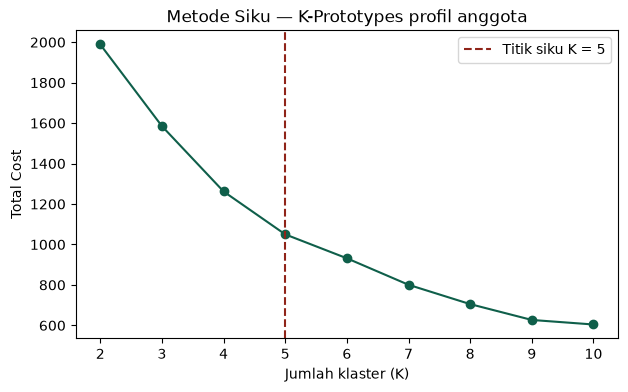

In [7]:
numerik, kategorikal, _ = R.member_feature_matrices(
    members, R.MEMBER_NUMERIC_COLUMNS, R.MEMBER_CATEGORICAL_COLUMNS
)
print("Atribut numerik    :", R.MEMBER_NUMERIC_COLUMNS)
print("Atribut kategorikal:", R.MEMBER_CATEGORICAL_COLUMNS)
print("Bobot kategorikal  :", dict(zip(R.MEMBER_CATEGORICAL_COLUMNS, R.member_categorical_weights())))
print()

kurva_anggota = R.member_cost_curve(numerik, kategorikal)
tabel_siku = R.elbow_table([b[0] for b in kurva_anggota], [b[1] for b in kurva_anggota],
                           cost_label="Total Cost")
display(tabel_siku)

K_anggota, label_anggota, _, _ = R.search_member_clusters(numerik, kategorikal)
print(f"K yang dipakai aplikasi: {K_anggota}")

fig, ax = plt.subplots()
ax.plot(tabel_siku["K"], tabel_siku["Total Cost"], marker="o", color="#0F5F4A")
ax.axvline(K_anggota, color="#8F2419", linestyle="--", label=f"Titik siku K = {K_anggota}")
ax.set_xlabel("Jumlah klaster (K)"); ax.set_ylabel("Total Cost")
ax.set_title("Metode Siku — K-Prototypes profil anggota"); ax.legend(); plt.show()

#### Isi tiap klaster anggota

In [8]:
profil = members.assign(K=label_anggota + 1)
ringkas_anggota = profil.groupby("K").agg(
    Anggota=("Age", "size"),
    Umur=("Age", "mean"),
    Berat=("Weight (kg)", "mean"),
    BMI=("BMI", "mean"),
).round(1)
for kolom in R.MEMBER_CATEGORICAL_COLUMNS:
    ringkas_anggota[kolom] = profil.groupby("K")[kolom].agg(
        lambda s: f"{s.value_counts().index[0]} ({s.value_counts(normalize=True).iloc[0]:.0%})"
    )
display(ringkas_anggota)

print("Sebaran tujuan kebugaran per klaster:")
display(pd.crosstab(profil["K"], profil["Fitness_Goal"]))

,Anggota,Umur,Berat,BMI,Gender,Activity_Level,Experience_Label,Fitness_Goal
K,,,,,,,,
1,171,40.5,50.7,16.3,Female (56%),Medium (50%),Beginner (48%),Gain Weight (98%)
2,128,38.1,66.4,20.9,Male (55%),Very High (39%),Expert (39%),Maintain Weight (100%)
3,131,38.6,76.8,26.7,Male (64%),Very High (100%),Expert (100%),Lose Weight (100%)
4,254,39.2,76.8,26.8,Female (64%),Medium (90%),Beginner (87%),Lose Weight (98%)
5,289,37.5,86.9,29.3,Male (65%),High (90%),Intermediate (85%),Lose Weight (100%)


Sebaran tujuan kebugaran per klaster:


Fitness_Goal,Gain Weight,Lose Weight,Maintain Weight
K,,,
1,168,0,3
2,0,0,128
3,0,131,0
4,0,250,4
5,0,289,0


#### Peran klaster anggota: segmentasi, bukan personalisasi

Klaster pengguna ditampilkan sebagai label segmen dan dipakai membuktikan bahwa
segmentasi sejalan dengan mandat BMI. Ia **tidak** dipakai menyusun rekomendasi
menu maupun latihan — dan itu keputusan yang diambil setelah diuji.

Uji di bawah menjawab pertanyaannya secara langsung: **kalau klaster dipakai
menggantikan profil individu, seberapa jauh melesetnya?**

In [9]:
from src.nutrition import calculate_nutrition_targets

target_per_anggota = []
for _, baris in members.iterrows():
    tinggi_cm = float(baris["Height (m)"])
    tinggi_cm = tinggi_cm * 100 if tinggi_cm < 3 else tinggi_cm
    gizi_anggota = calculate_nutrition_targets(
        gender=baris["Gender"], weight_kg=float(baris["Weight (kg)"]),
        height_cm=tinggi_cm, age=int(baris["Age"]),
        activity_level=baris["Activity_Level"],
        fitness_goal=R.normalize_goal(baris["Fitness_Goal"]),
    )
    target_per_anggota.append(gizi_anggota.target_calories)

sebaran_target = members.assign(Target=target_per_anggota).groupby("User_Cluster")["Target"].agg(
    Anggota="size", Terendah="min", Tertinggi="max", Rerata="mean", Simpangan="std"
).round(0)
sebaran_target["Selisih dalam klaster"] = (
    sebaran_target["Tertinggi"] - sebaran_target["Terendah"]
).round(0)
display(sebaran_target)

# Kemurnian tujuan: seberapa sejalan klaster dengan mandat BMI.
tujuan_modus = (
    pd.DataFrame({"K": members["User_Cluster"], "g": members["Fitness_Goal"]})
    .groupby("K")["g"].agg(lambda s: s.value_counts().index[0])
)
sesuai = members["Fitness_Goal"].to_numpy() == members["User_Cluster"].map(tujuan_modus).to_numpy()
print(f"Kemurnian tujuan di dalam klaster : {sesuai.mean():.1%}")
print(f"Selisih target kalori TERBESAR    : "
      f"{int(sebaran_target['Selisih dalam klaster'].max()):,} kkal/hari, di dalam SATU klaster")

,Anggota,Terendah,Tertinggi,Rerata,Simpangan,Selisih dalam klaster
User_Cluster,,,,,,
1,171,1618,2994,2237.0,321.0,1376
2,128,1455,3437,2378.0,450.0,1982
3,131,1350,2945,2228.0,466.0,1595
4,254,1200,2785,1642.0,426.0,1585
5,289,1200,3213,2110.0,509.0,2013


Kemurnian tujuan di dalam klaster : 99.3%
Selisih target kalori TERBESAR    : 2,013 kkal/hari, di dalam SATU klaster


Kedua angka itu harus dibaca bersama:

- **Kemurnian tujuan tinggi** — klaster memang menyatu pada tujuan kebugaran,
  dan itulah yang membuatnya sejalan dengan mandat BMI.
- **Selisih target kalori di dalam klaster besar** — klaster menyatu pada
  *tujuan*, bukan pada *tubuh*. Anggota dengan tujuan sama bisa berbeda umur
  puluhan tahun dan berbeda BMI belasan poin.

Karena itu klaster tidak layak dijadikan dasar porsi. Yang dikandungnya tetap
sampai ke rekomendasi — lewat `Fitness_Goal`, yang sekaligus atribut pembentuk
klaster dan masukan langsung rekomendasi.

---

### 2.2 K-Means — menu makanan

Fiturnya empat makronutrien **ditambah kepadatan protein** (gram protein per
100 kkal). Kepadatan adalah rasio, dan tanpa sumbu itu kelompok "protein ramping"
mustahil ditemukan berapa pun nilai K — K-Means hanya bisa menemukan kelompok di
sepanjang sumbu yang diberikan padanya.

Fitur K-Means: ['calories', 'proteins', 'fat', 'carbohydrate', 'Protein_Density']
Bentuk matriks fitur: (780, 5)



,K,WCSS,Penurunan,Jarak ke garis,Titik siku
0,2,92.8019,NaN,0.0000,
1,3,67.2741,25.5278,0.1601,
2,4,49.2358,18.0383,0.2474,
3,5,39.8822,9.3536,0.2501,<-- K dipilih
4,6,33.1075,6.7747,0.2276,
5,7,28.6716,4.4358,0.1824,
6,8,24.8836,3.7880,0.1309,
7,9,22.5516,2.3319,0.0652,
8,10,20.1730,2.3786,0.0000,


K yang dipakai aplikasi: 4
Titik siku kurva WCSS  : 5


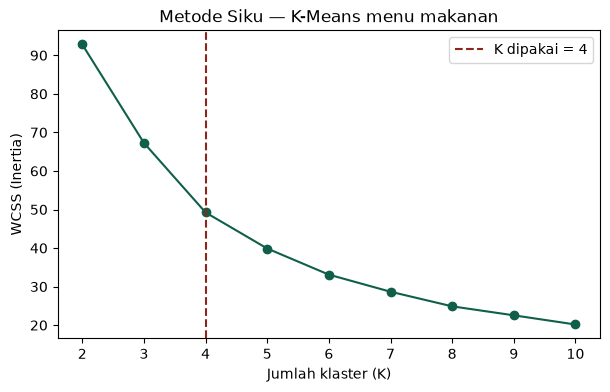

In [10]:
X_menu = R.food_cluster_features(foods)
print("Fitur K-Means:", R.FOOD_MACRO_COLUMNS + [R.FOOD_PROTEIN_DENSITY_COLUMN])
print("Bentuk matriks fitur:", X_menu.shape)
print()

K_RANGE = list(R.CLUSTER_SEARCH_RANGE)
wcss = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_menu).inertia_ for k in K_RANGE]
tabel_menu = R.elbow_table(K_RANGE, wcss, cost_label="WCSS")
display(tabel_menu)

print(f"K yang dipakai aplikasi: {R.FOOD_CLUSTER_COUNT}")
print(f"Titik siku kurva WCSS  : {R.elbow_cluster_count(K_RANGE, wcss)}")

fig, ax = plt.subplots()
ax.plot(K_RANGE, wcss, marker="o", color="#0F5F4A")
ax.axvline(R.FOOD_CLUSTER_COUNT, color="#8F2419", linestyle="--",
           label=f"K dipakai = {R.FOOD_CLUSTER_COUNT}")
ax.set_xlabel("Jumlah klaster (K)"); ax.set_ylabel("WCSS (Inertia)")
ax.set_title("Metode Siku — K-Means menu makanan"); ax.legend(); plt.show()

**Kenapa K = 4 dan bukan titik sikunya?** K = 4 adalah keputusan struktural:
`MEAL_TEMPLATES` menyusun menu dari empat peran gizi, dan tiap peran harus bisa
diminta per slot. Jaraknya ke garis praktis menyamai titik siku, dan klaster
tambahan yang ditawarkan siku hanya memecah karbohidrat jadi dua tingkat — bukan
menambah peran gizi baru. Perbandingannya ada di komentar `FOOD_CLUSTER_COUNT`
pada `src/recommender.py`.

#### Isi tiap klaster menu

In [11]:
peran_menu = {"A": "Tinggi karbohidrat", "B": "Protein ramping",
              "C": "Rendah kalori", "D": "Protein berlemak"}

ringkas_menu = foods.groupby("Food_Cluster")[R.FOOD_MACRO_COLUMNS].median().round(1)
ringkas_menu.insert(0, "Menu", foods.groupby("Food_Cluster").size())
ringkas_menu["g protein/100 kkal"] = (
    foods.assign(d=foods["proteins"] / foods["calories"] * 100)
    .groupby("Food_Cluster")["d"].median().round(1)
)
ringkas_menu["% kkal dari lemak"] = (
    foods.assign(q=foods["fat"] * 9 / foods["calories"] * 100)
    .groupby("Food_Cluster")["q"].median().round(0)
)
ringkas_menu.insert(0, "Peran", [peran_menu[k] for k in ringkas_menu.index])
display(ringkas_menu)

print("Contoh menu berprotein tertinggi tiap klaster:")
for kode in sorted(foods["Food_Cluster"].unique()):
    contoh = foods[foods["Food_Cluster"] == kode].nlargest(4, "proteins")["name"].tolist()
    print(f"  {kode} ({peran_menu[kode]:18s}): " + ", ".join(str(x)[:26] for x in contoh))

,Peran,Menu,calories,proteins,fat,carbohydrate,g protein/100 kkal,% kkal dari lemak
Food_Cluster,,,,,,,,
A,Tinggi karbohidrat,158,345.0,4.7,4.4,64.5,1.5,14.0
B,Protein ramping,129,148.0,16.0,6.5,2.7,10.6,39.0
C,Rendah kalori,392,111.0,2.2,1.4,18.5,2.0,11.0
D,Protein berlemak,101,425.0,12.9,29.9,28.4,3.2,62.0


Contoh menu berprotein tertinggi tiap klaster:
  A (Tinggi karbohidrat): Kacang Endel biji, Lamtoro var. lokal dengan , Kacang Tunggak (tolo), Kacang Gude biji
  B (Protein ramping   ): Kerupuk Kulit kerbau, Ikan Mujair goreng, Lamtoro var. gung tanpa ku, Cumi-cumi goreng
  C (Rendah kalori     ): Oncom, Oncom Kedele, Fillet o-fish, Pempek kelesan
  D (Protein berlemak  ): Kerupuk urat, Ayam usus goreng, Keripik tempe abadi murni, Kripik Tempe Goreng 


#### Susunan menu harian per tujuan

Peran gizi itulah yang dipakai `MEAL_TEMPLATES` untuk menyusun menu, dan
susunannya berbeda untuk tiap tujuan kebugaran.

In [12]:
susunan = []
for tujuan in ["Lose Weight", "Maintain Weight", "Gain Weight"]:
    template = R.meal_template(tujuan)
    baris = {"Tujuan": tujuan}
    baris.update({slot: " + ".join(peran) for slot, peran in template.items()})
    semua = [p for peran in template.values() for p in peran]
    baris["Komposisi"] = "".join(sorted(semua))
    susunan.append(baris)
display(pd.DataFrame(susunan))
print("Peran D (protein berlemak) hanya muncul pada tujuan menaikkan berat.")

,Tujuan,Breakfast,Lunch,Snack,Dinner,Komposisi
0,Lose Weight,B + C,A + B + C,C,B + C,ABBBCCCC
1,Maintain Weight,A + B,A + B + C,C,B + C,AABBBCCC
2,Gain Weight,A + B,A + B + D,A,A + C,AAAABBCD


Peran D (protein berlemak) hanya muncul pada tujuan menaikkan berat.


### 2.3 K-Modes — program latihan

Jarak Hamming memberi tiap atribut nilai 0 atau 1, yang terlihat adil tetapi
tidak: atribut yang isinya nyaris seragam hampir tidak pernah ikut membedakan.
`categorical_attribute_weights()` menyeimbangkannya dengan bobot berbanding
terbalik terhadap peluang tiap atribut berbeda.

,Atribut,Kategori,Kategori terbanyak,Bobot
0,Type,7,Strength (90%),1.549
1,BodyPart,16,Abdominals (22%),0.320
2,Equipment,12,Body Only (30%),0.335
3,Level,3,Intermediate (92%),1.795


,K,Hamming Cost berbobot,Penurunan,Jarak ke garis,Titik siku
0,2,875.7574,NaN,0.0000,
1,3,750.9113,124.8461,0.1334,
2,4,661.8703,89.0410,0.2031,
3,5,593.8148,68.0555,0.2356,<-- K dipilih
4,6,588.3939,5.4209,0.1569,
5,7,532.3837,56.0102,0.1680,
6,8,574.9726,-42.5888,0.0039,
7,9,542.3841,32.5884,0.0266,
8,10,477.6511,64.7330,0.0000,


K yang dipakai aplikasi: 5


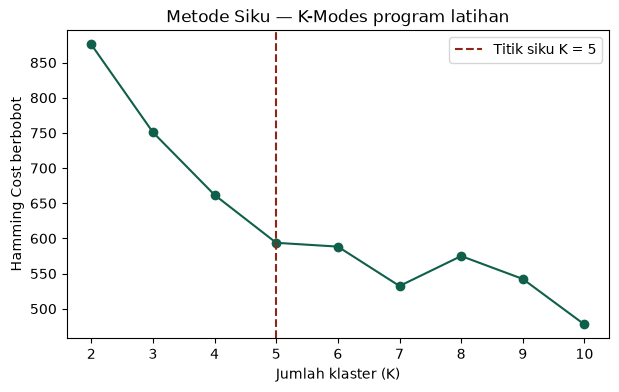

In [13]:
atribut_latihan = R.exercise_cluster_features(exercises)
nilai_latihan = atribut_latihan.astype(str).to_numpy()
bobot_latihan = R.categorical_attribute_weights(nilai_latihan)

sebaran = pd.DataFrame({
    "Atribut": atribut_latihan.columns,
    "Kategori": [atribut_latihan[k].nunique() for k in atribut_latihan.columns],
    "Kategori terbanyak": [
        f"{atribut_latihan[k].value_counts().index[0]} "
        f"({atribut_latihan[k].value_counts(normalize=True).iloc[0]:.0%})"
        for k in atribut_latihan.columns
    ],
    "Bobot": bobot_latihan.round(3),
})
display(sebaran)

kurva_latihan = R.exercise_cost_curve(atribut_latihan)
tabel_latihan = R.elbow_table([b[0] for b in kurva_latihan], [b[1] for b in kurva_latihan],
                              cost_label="Hamming Cost berbobot")
display(tabel_latihan)

K_latihan, label_latihan, _ = R.search_exercise_clusters(atribut_latihan)
print(f"K yang dipakai aplikasi: {K_latihan}")

fig, ax = plt.subplots()
ax.plot(tabel_latihan["K"], tabel_latihan["Hamming Cost berbobot"], marker="o", color="#0F5F4A")
ax.axvline(K_latihan, color="#8F2419", linestyle="--", label=f"Titik siku K = {K_latihan}")
ax.set_xlabel("Jumlah klaster (K)"); ax.set_ylabel("Hamming Cost berbobot")
ax.set_title("Metode Siku — K-Modes program latihan"); ax.legend(); plt.show()

#### Isi tiap klaster latihan

In [14]:
profil_latihan = exercises.assign(K=label_latihan)
ringkas_latihan = pd.DataFrame({"Latihan": profil_latihan.groupby("K").size()})
for kolom in atribut_latihan.columns:
    ringkas_latihan[kolom] = profil_latihan.groupby("K")[kolom].agg(
        lambda s: f"{s.value_counts().index[0]} ({s.value_counts(normalize=True).iloc[0]:.0%})"
    )
display(ringkas_latihan)

print("Sebaran jenis latihan per klaster:")
display(pd.crosstab(profil_latihan["K"], profil_latihan["Type"]))

,Latihan,Type,BodyPart,Equipment,Level
K,,,,,
0,481,Strength (94%),Quadriceps (25%),Cable (29%),Intermediate (99%)
1,78,Plyometrics (62%),Quadriceps (51%),Body Only (78%),Intermediate (97%)
2,393,Strength (99%),Abdominals (62%),Body Only (80%),Intermediate (100%)
3,105,Strength (84%),Chest (29%),Body Only (29%),Beginner (100%)
4,302,Strength (99%),Shoulders (46%),Dumbbell (76%),Intermediate (100%)


Sebaran jenis latihan per klaster:


Type,Cardio,Olympic Weightlifting,Plyometrics,Powerlifting,Strength,Stretching,Strongman
K,,,,,,,
0,8,3,0,8,453,5,4
1,8,0,48,0,0,22,0
2,0,0,0,0,389,4,0
3,1,0,4,2,88,10,0
4,0,2,0,1,298,1,0


---

## 3. Pengujian Rekomendasi CBF

**Content-Based Filtering dipakai pada kedua rekomendasi.** Tiap item diwakili
teks `CBF_Text`, diubah jadi vektor TF-IDF, lalu diperingkat dengan cosine
similarity terhadap kueri yang dirakit dari masukan pengguna.

Perbedaan keduanya ada pada apa yang dikerjakan CBF:

| | Struktur ditentukan oleh | CBF memutuskan |
| --- | --- | --- |
| Menu makanan | Peran gizi K-Means + `MEAL_TEMPLATES` per tujuan | menu mana yang mengisi tiap slot |
| Program latihan | Komposisi jenis dari tujuan + prioritas alat per level | latihan mana yang mengisi tiap kuota jenis |

Pola yang sama pada keduanya: **klasterisasi membangun rangkanya, CBF mengisi
dagingnya.**

### 3.1 Akurasi peringkat CBF menu makanan

Untuk tiap kategori bahan utama, seluruh menu diperingkat terhadap kueri
kategori itu. Sebuah hasil dianggap **relevan** bila menu itu memang termasuk
kategori yang diminta menurut `food_category_mask()` — fungsi yang sama yang
dipakai aplikasi sebagai kunci pengurutan pertama. Diukur dengan MAP dan NDCG
pada K = 5 dan 10.

**Kunci jawabannya pernah salah, dan itu perlu dicatat.** Versi sebelumnya
menilai relevansi dengan `Food_Category`, yaitu keluaran
`primary_food_category()`. Fungsi itu memberi **satu** label per menu dengan
aturan *kategori pertama dalam daftar yang cocok yang menang*, karena tugasnya
memilih chip yang tampil di kartu menu — bukan menjadi kunci jawaban pengujian.

Akibatnya "Keripik tempe" berlabel `Tahu, Tempe & Oncom` (urutan ke-6) dan bukan
`Kerupuk & Keripik` (urutan ke-13). Untuk kueri "Kerupuk & Keripik", CBF
mengembalikan Keripik tempe, Keripik singkong, Keripik oncom, Keripik ubi, dan
Keripik kentang di lima besar — **kelimanya benar-benar keripik, dan kelimanya
dihitung salah**, sehingga AP@5 kategori itu 0,0000. Total ada **67 menu** yang
lolos `food_category_mask()` tetapi berlabel utama lain.

Aplikasi sendiri tidak pernah memakai definisi sempit itu untuk memilih menu; ia
memakai `food_category_mask()`, yang mengizinkan satu menu masuk lebih dari satu
kategori. Pengujian di bawah kini memakai definisi yang sama dengan aplikasinya.

**Pengujian ini pernah mengukur hal yang salah, dan itu perlu dicatat.** Versi
sebelumnya merangkai `CBF_Text` sebagai nama + keempat makro + label klaster +
`"kategori <Food_Category>"`. Karena `Food_Category` juga label yang dipakai
menilai relevansi, evaluasinya mengukur pencocokan sebuah kata dengan dirinya
sendiri — dan menghasilkan **MAP@5 = 1,0000** yang menyesatkan.

Kebocorannya sudah **diperbaiki di sumbernya**: `CBF_Text` kini berisi nama menu
saja. Kategori tetap bekerja sebagai penyaring lewat `_category`, yang merupakan
kunci pengurutan pertama di `_rank_foods()`. Jadi tidak ada yang perlu dilucuti
saat pengujian — angka di bawah sah apa adanya.

In [15]:
K_EVAL = (5, 10)
kategori_uji = [k for k in R.available_food_categories(foods) if k != R.OTHER_CATEGORY]
print(f"Kueri diuji: {len(kategori_uji)} kategori bahan utama")
print("Contoh CBF_Text:", repr(foods["CBF_Text"].iloc[0]))

vectorizer = TfidfVectorizer(stop_words="english")
tfidf = vectorizer.fit_transform(foods["CBF_Text"])
print("Ukuran matriks TF-IDF:", tfidf.shape)
print()

relevansi_menu = {}
for label_kategori in kategori_uji:
    kueri = R.build_preference_query("", [label_kategori])
    skor = cosine_similarity(vectorizer.transform([kueri]), tfidf).ravel()
    urutan = np.argsort(-skor, kind="stable")
    lolos = R.food_category_mask(foods, label_kategori).to_numpy()
    relevansi_menu[label_kategori] = lolos[urutan]

map_menu = {k: RM.mean_average_precision(relevansi_menu.values(), k) for k in K_EVAL}
ndcg_menu = {k: RM.mean_ndcg(relevansi_menu.values(), k) for k in K_EVAL}
for k in K_EVAL:
    print(f"MAP@{k:<3}= {map_menu[k]:.4f}      NDCG@{k:<3}= {ndcg_menu[k]:.4f}")

Kueri diuji: 15 kategori bahan utama
Contoh CBF_Text: 'Abon'
Ukuran matriks TF-IDF: (780, 722)

MAP@5  = 0.8909      NDCG@5  = 0.9206
MAP@10 = 0.8770      NDCG@10 = 0.9150


Sebagai pembanding, sel berikut membangun ulang representasi lama itu &mdash;
nama + keempat makro + label klaster, tanpa kategori &mdash; lalu mengukurnya
dengan kunci jawaban yang sama.

Yang perlu dicatat jujur: **selisih ketepatannya tipis.** Membuang angka dan
label klaster tidak menaikkan MAP secara berarti &mdash; ia juga tidak
menurunkannya, padahal kosakatanya menyusut sepertiga. Itulah temuannya:
seluruh rangkaian makro dan label klaster **tidak menyumbang apa pun** pada
peringkat. Sebabnya dua, dan keduanya bisa dihitung: 376 dari 1.110 token
kosakata lama berupa angka yang tidak pernah muncul di kueri mana pun sehingga
mustahil dicocokkan, sementara kata seperti `calories` atau `cluster` dimiliki
setiap dokumen sehingga ber-IDF nol.

Pembenaran membuangnya karena itu bukan &ldquo;lebih akurat&rdquo;, melainkan
**menghilangkan kebocoran label tanpa membayar apa pun** &mdash; ditambah
korpus yang sepertiga lebih ringkas.

In [16]:
teks_lama = (
    foods["name"].fillna("").astype(str)
    + " " + foods["calories"].astype(str) + " calories"
    + " " + foods["proteins"].astype(str) + " protein"
    + " " + foods["fat"].astype(str) + " fat"
    + " " + foods["carbohydrate"].astype(str) + " carbohydrate"
    + " cluster " + foods["Food_Cluster"].astype(str)
)
vec_lama = TfidfVectorizer(stop_words="english")
tfidf_lama = vec_lama.fit_transform(teks_lama)

rel_lama = {}
for label_kategori in kategori_uji:
    kueri = R.build_preference_query("", [label_kategori])
    skor = cosine_similarity(vec_lama.transform([kueri]), tfidf_lama).ravel()
    rel_lama[label_kategori] = R.food_category_mask(
        foods, label_kategori).to_numpy()[np.argsort(-skor, kind="stable")]

display(pd.DataFrame([
    {"Representasi CBF_Text": "nama + makro + klaster (lama)",
     "Ukuran kosakata": len(vec_lama.vocabulary_),
     "MAP@5": round(RM.mean_average_precision(rel_lama.values(), 5), 4),
     "NDCG@5": round(RM.mean_ndcg(rel_lama.values(), 5), 4)},
    {"Representasi CBF_Text": "nama menu saja (dipakai)",
     "Ukuran kosakata": len(vectorizer.vocabulary_),
     "MAP@5": round(map_menu[5], 4),
     "NDCG@5": round(ndcg_menu[5], 4)},
]))

,Representasi CBF_Text,Ukuran kosakata,MAP@5,NDCG@5
0,nama + makro + klaster (lama),1101,0.8887,0.9191
1,nama menu saja (dipakai),722,0.8909,0.9206


#### Mengapa angkanya bukan mendekati 1,0

Dua sebab yang terukur, keduanya di luar kendali CBF.

**1. Kosakata kueri tidak sama dengan kosakata nama menu.** Kueri memakai *nama
tampilan* kategori, sedangkan nama menu memakai kata sehari-hari. Token
`"sayuran"` hanya muncul di **1** dari 973 nama menu, padahal 40 nama memuat
`"sayur"`. Token `"olahan"` dan `"olahannya"` tidak muncul sama sekali. Untuk
kueri seperti itu TF-IDF nyaris tidak punya bahan, dan peringkat di bawahnya
jatuh ke urutan seri bernilai nol.

**2. Pengujian ini menjalankan TF-IDF sendirian.** Di aplikasi, `_rank_foods()`
mengurutkan dengan empat kunci — `_category` → `_match` → `_nutrition` →
`_score` (TF-IDF) — lalu menyaring ulang untuk keragaman. Kategori adalah kunci
**pertama**, jadi TF-IDF tidak pernah diminta menebak kategori; ia hanya
mengurutkan di dalam kolam yang kategorinya sudah benar. Sel di bawah
memperlihatkan selisihnya.

Angka pipeline penuh itu **tidak dilaporkan sebagai akurasi CBF**, dan alasannya
penting: kunci urut pertamanya memakai fungsi yang sama dengan kunci jawabannya,
jadi yang terukur adalah sebuah penyaring — dan penyaring selalu benar 100 %.
Yang sah dilaporkan tetap angka TF-IDF sendirian di atas, karena di sana kueri
hanya melihat nama tampilan kategori sementara kunci jawabannya berisi kosakata
(`bayam`, `kangkung`, `wortel`, …) yang tidak pernah masuk ke kueri.

In [17]:
baris_bukti = []
for label_kategori in kategori_uji:
    kueri = R.build_preference_query("", [label_kategori])
    skor = cosine_similarity(vectorizer.transform([kueri]), tfidf).ravel()
    urutan_tfidf = np.argsort(-skor, kind="stable")[:5]
    lolos = R.food_category_mask(foods, label_kategori)
    penuh = R._rank_foods(foods, "", [label_kategori],
                          vectorizer=vectorizer, tfidf=tfidf).head(5).index
    baris_bukti.append({
        "Kategori": label_kategori,
        "Menu kena TF-IDF": int((skor > 0).sum()),
        "Benar@5 TF-IDF saja": int(lolos.to_numpy()[urutan_tfidf].sum()),
        "Benar@5 pipeline penuh": int(lolos.loc[penuh].sum()),
    })
bukti = pd.DataFrame(baris_bukti)
display(bukti)
print(f"TF-IDF sendirian : {bukti['Benar@5 TF-IDF saja'].sum():>2}/{5 * len(kategori_uji)} slot benar")
print(f"Pipeline penuh   : {bukti['Benar@5 pipeline penuh'].sum():>2}/{5 * len(kategori_uji)} slot benar")

,Kategori,Menu kena TF-IDF,Benar@5 TF-IDF saja,Benar@5 pipeline penuh
0,Ayam,26,5,5
1,Ikan & Seafood,34,5,5
2,Daging Sapi,18,3,5
3,Daging Kambing,15,1,1
4,Telur,16,5,5
5,"Tahu, Tempe & Oncom",46,5,5
6,Sayuran,1,1,5
7,Kacang-kacangan,45,5,5
8,Nasi & Olahan Beras,31,5,5
9,Mie & Bihun,15,5,5


TF-IDF sendirian : 64/75 slot benar
Pipeline penuh   : 71/75 slot benar


#### Rincian per kueri

In [18]:
display(RM.ranking_report(relevansi_menu, K_EVAL))

,Kueri,Item relevan,AP@5,NDCG@5,AP@10,NDCG@10
0,Ayam,23,1.0000,1.0000,1.0000,1.0000
1,Ikan & Seafood,59,1.0000,1.0000,1.0000,1.0000
2,Daging Sapi,21,0.5200,0.6844,0.3656,0.5798
3,Daging Kambing,1,1.0000,1.0000,1.0000,1.0000
4,Telur,16,1.0000,1.0000,1.0000,1.0000
5,"Tahu, Tempe & Oncom",46,1.0000,1.0000,1.0000,1.0000
6,Sayuran,81,0.2000,0.3392,0.1633,0.3621
7,Kacang-kacangan,45,1.0000,1.0000,1.0000,1.0000
8,Nasi & Olahan Beras,49,1.0000,1.0000,1.0000,1.0000
9,Mie & Bihun,17,1.0000,1.0000,1.0000,1.0000


### 3.2 Pembanding: peringkat acak

Angka MAP dan NDCG tidak berarti apa-apa tanpa pembanding. Kolom "acak" adalah
rata-rata 200 pengacakan atas himpunan relevansi yang sama persis — jadi ia
mengukur berapa nilai yang bisa dicapai tanpa model sama sekali. Pembandingnya berbagi
persis ukuran korpus dan sebaran relevansinya.

In [19]:
acak = RM.random_baseline(relevansi_menu, K_EVAL).set_index("K")
banding = []
for k in K_EVAL:
    banding.append({
        "K": k,
        "MAP (CBF)": round(map_menu[k], 4),
        "MAP (acak)": round(float(acak.loc[k, "MAP acak"]), 4),
        "Berapa kali lipat": round(map_menu[k] / float(acak.loc[k, "MAP acak"]), 1),
        "NDCG (CBF)": round(ndcg_menu[k], 4),
        "NDCG (acak)": round(float(acak.loc[k, "NDCG acak"]), 4),
    })
display(pd.DataFrame(banding))

,K,MAP (CBF),MAP (acak),Berapa kali lipat,NDCG (CBF),NDCG (acak)
0,5,0.8909,0.0237,37.6,0.9206,0.0475
1,10,0.8770,0.0165,53.2,0.9150,0.0478


### 3.3 Menguji CBF penuh: penyaring atribut + TF-IDF sekaligus

CBF di sistem ini bukan TF-IDF saja. Ia **penyaring atribut langsung sebagai
kunci utama, ditambah pembobotan TF-IDF dan cosine similarity** atas
representasi teks item. Wajar kalau muncul pertanyaan: kenapa yang diuji di
&sect;3.1 hanya bagian TF-IDF-nya, bukan CBF penuh?

Jawabannya: CBF penuh **sudah** diuji, dan hasilnya di bawah. Yang perlu
dicatat adalah cara membacanya.

In [20]:
POSISI = {ix: i for i, ix in enumerate(foods.index)}

def urutan_pipeline(preferensi, kategori, tujuan=None):
    """Urutan hasil _rank_foods() -- CBF penuh, keempat kuncinya.

    `tujuan` WAJIB diteruskan kalau kunci jawabannya berkaitan dengan gizi:
    tanpa itu `_nutrition` dihitung memakai tujuan bawaan, sehingga yang diukur
    bukan susunan yang benar-benar diterima pengguna dengan tujuan itu.
    """
    hasil = R._rank_foods(foods, preferensi, kategori,
                          vectorizer=vectorizer, tfidf=tfidf, fitness_goal=tujuan)
    return np.array([POSISI[i] for i in hasil.index])

def acak_dalam_kolam(kolam, relevan, ulang=200, benih=0):
    """MAP@5 bila urutan DI DALAM kolam penyaring diacak.

    Ini lantai pembanding yang sah untuk penyaring keras. Membandingkan sebuah
    penyaring dengan acak GLOBAL cuma mengukur penyaringnya; yang ingin
    diketahui adalah sumbangan pengurutan SETELAH penyaring bekerja.
    """
    rng = np.random.default_rng(benih)
    di_dalam, di_luar = np.flatnonzero(kolam), np.flatnonzero(~kolam)
    return float(np.mean([
        RM.average_precision_at_k(relevan[np.concatenate(
            [rng.permutation(di_dalam), rng.permutation(di_luar)])], 5)
        for _ in range(ulang)
    ]))

baris_penuh = []
for label_kategori in kategori_uji:
    kolam = R.food_category_mask(foods, label_kategori).to_numpy()
    urut = urutan_pipeline("", [label_kategori])
    baris_penuh.append({
        "Kategori": label_kategori,
        "AP@5 CBF penuh": round(RM.average_precision_at_k(kolam[urut], 5), 4),
        "AP@5 acak dalam kolam": round(acak_dalam_kolam(kolam, kolam), 4),
    })
penuh = pd.DataFrame(baris_penuh)
display(penuh)
print(f"MAP@5 CBF penuh          : {penuh['AP@5 CBF penuh'].mean():.4f}")
print(f"MAP@5 acak di dalam kolam: {penuh['AP@5 acak dalam kolam'].mean():.4f}")

,Kategori,AP@5 CBF penuh,AP@5 acak dalam kolam
0,Ayam,1.0,1.0
1,Ikan & Seafood,1.0,1.0
2,Daging Sapi,1.0,1.0
3,Daging Kambing,1.0,1.0
4,Telur,1.0,1.0
5,"Tahu, Tempe & Oncom",1.0,1.0
6,Sayuran,1.0,1.0
7,Kacang-kacangan,1.0,1.0
8,Nasi & Olahan Beras,1.0,1.0
9,Mie & Bihun,1.0,1.0


MAP@5 CBF penuh          : 1.0000
MAP@5 acak di dalam kolam: 1.0000


**MAP@5 = 1,0000 &mdash; dan justru itu masalahnya.** Kolom kedua menunjukkan
bahwa **mengacak isi kolam pun tetap memberi 1,0000**. Sebuah ukuran yang
memberi nilai sama kepada sistem sungguhan dan kepada pengacakan tidak sedang
mengukur sistem itu; ia mengukur penyaringnya. Dan penyaring memang selalu
benar &mdash; itu memang tugasnya.

Sebabnya struktural, bukan kebetulan: `_category` dan `_match`, dua kunci
pengurutan teratas, keduanya **aturan pencocokan persis atas nama item**. Maka
setiap definisi relevansi yang dirumuskan lewat nama item pasti bisa dihitung
oleh kedua kunci itu, sehingga tidak pernah bisa mengujinya. Mengganti kueri
kategori dengan kueri teks bebas (`"goreng"`, `"bakar"`, `"pepes"`) pun tetap
memberi 1,0000, karena `match_food_keywords()` persis berarti "nama memuat kata
kunci itu".

Karena itu &sect;3.1 menguji bagian TF-IDF secara terpisah: **TF-IDF adalah
satu-satunya bagian CBF yang menghasilkan skor bergradasi, bukan menjalankan
aturan ya/tidak.** Hanya di situ pertanyaan "seberapa baik urutannya" punya
arti.

Dua ukuran di bawah ini melengkapinya, dan keduanya menguji CBF penuh.

#### 3.3.1 Kepatuhan preferensi, end-to-end

Ukuran yang sah untuk CBF penuh bukan MAP, melainkan **kepatuhan kendala**:
dari menu harian yang benar-benar diterima pengguna, berapa bagian yang sesuai
kategori yang ia minta? Ini punya keragaman nyata &mdash; templat menu bisa
mengalahkan preferensi &mdash; jadi angkanya bukan 100 % otomatis.

In [21]:
from src.nutrition import calculate_nutrition_targets

PROFIL_UJI = [
    ("Pria obesitas",  dict(gender="Male",   weight_kg=95.0, height_cm=172.0,
                            age=28, activity_level="Sedang"), "Lose Weight"),
    ("Wanita gemuk",   dict(gender="Female", weight_kg=72.0, height_cm=158.0,
                            age=34, activity_level="Ringan"), "Lose Weight"),
    ("Pria normal",    dict(gender="Male",   weight_kg=68.0, height_cm=175.0,
                            age=22, activity_level="Berat"),  "Maintain Weight"),
    ("Wanita normal",  dict(gender="Female", weight_kg=54.0, height_cm=162.0,
                            age=25, activity_level="Sedang"), "Maintain Weight"),
    ("Pria kurus",     dict(gender="Male",   weight_kg=52.0, height_cm=173.0,
                            age=20, activity_level="Sedang"), "Gain Weight"),
]

baris_patuh, meleset_per_kategori = [], {}
for nama_profil, atribut, tujuan in PROFIL_UJI:
    gizi = calculate_nutrition_targets(fitness_goal=tujuan, **atribut)
    jumlah_item = jumlah_sesuai = 0
    for label_kategori in kategori_uji:
        menu = R.recommend_foods(foods, gizi, categories=[label_kategori],
                                 fitness_goal=tujuan)
        isi = [i for slot in menu.values() for i in slot]
        sesuai = sum(1 for i in isi if bool(R.food_category_mask(
            foods[foods["id"] == i["id"]], label_kategori).iloc[0]))
        jumlah_item += len(isi)
        jumlah_sesuai += sesuai
        meleset_per_kategori[label_kategori] = (
            meleset_per_kategori.get(label_kategori, 0) + len(isi) - sesuai)
    baris_patuh.append({
        "Profil": nama_profil, "Tujuan": tujuan,
        "Target kkal": round(gizi.target_calories),
        "Item menu": jumlah_item, "Sesuai kategori": jumlah_sesuai,
        "Kepatuhan": round(jumlah_sesuai / jumlah_item, 3),
    })

patuh = pd.DataFrame(baris_patuh)
display(patuh)
KEPATUHAN = patuh["Sesuai kategori"].sum() / patuh["Item menu"].sum()
print(f"KESELURUHAN: {patuh['Sesuai kategori'].sum()}/{patuh['Item menu'].sum()}"
      f" item sesuai = {KEPATUHAN:.1%}")
print()
print("Kategori penyumbang ketidaksesuaian terbesar:")
display(pd.Series(meleset_per_kategori, name="Item meleset")
        .sort_values(ascending=False).head(5).to_frame())

,Profil,Tujuan,Target kkal,Item menu,Sesuai kategori,Kepatuhan
0,Pria obesitas,Lose Weight,2099,120,98,0.817
1,Wanita gemuk,Lose Weight,1393,120,98,0.817
2,Pria normal,Maintain Weight,2295,120,98,0.817
3,Wanita normal,Maintain Weight,1741,120,98,0.817
4,Pria kurus,Gain Weight,2371,120,98,0.817


KESELURUHAN: 490/600 item sesuai = 81.7%

Kategori penyumbang ketidaksesuaian terbesar:


,Item meleset
Daging Kambing,39
Kerupuk & Keripik,35
Mie & Bihun,20
Nasi & Olahan Beras,11
Daging Sapi,5


**Sisa ketidaksesuaian itu bukan kegagalan penyaring, melainkan pagar bentuk
sajian dan templat tujuan yang sedang bekerja.** Ketiga penyumbang terbesarnya
punya sebab yang berbeda-beda dan seluruhnya bisa ditelusuri:

- **Kerupuk & Keripik** &mdash; `MAIN_MEAL_UNSUITABLE_PATTERN` melarang kerupuk,
  keripik, dan kudapan manis mengisi slot sarapan, makan siang, maupun makan
  malam. Ia tetap boleh muncul sebagai camilan. Pagar ini dipasang setelah
  dilaporkan dari pemakaian nyata bahwa &ldquo;kue dadar gulung&rdquo;, sebuah
  jajanan pasar, muncul sebagai menu makan siang.
- **Daging Kambing** &mdash; hanya punya 1 menu di dataset, jadi tujuh slot
  lainnya mustahil diisi kambing. Batas data, bukan kegagalan model.
- **Mie &amp; Bihun** &mdash; hanya satu makanan pokok yang boleh masuk per
  slot, sehingga mie tidak bisa mengisi slot yang pokoknya sudah terpakai.

Jadi angka ini mengukur hal yang benar-benar berarti: **seberapa jauh preferensi
pengguna dipenuhi tanpa melanggar mandat tujuan kebugarannya maupun kepantasan
waktu makannya.**

Pagar bentuk sajian itu berbayar, dan bayarannya terlihat: kepatuhan turun
karena kerupuk tidak lagi boleh mengisi slot utama. Yang didapat sebagai
gantinya ada di tabel ablasi &sect;3.3.2 &mdash; kerapatan kalori menu turun
tajam, karena kudapan manis yang tersingkir justru yang paling padat kalori.

In [22]:
kkal, prot = foods["calories"].astype(float), foods["proteins"].astype(float)
batas_kkal, batas_prot = kkal.quantile(0.33), prot.median()
print(f"Ambang menu cocok-gizi: kalori <= {batas_kkal:.0f} kkal "
      f"dan protein >= {batas_prot:.1f} g")

Ambang menu cocok-gizi: kalori <= 120 kkal dan protein >= 4.1 g


#### 3.3.2 Kesesuaian gizi &mdash; kunci jawaban di luar pipeline

Ukuran terakhir memakai kunci jawaban yang **tidak dipakai kunci pengurutan mana
pun**: sebuah menu disebut relevan bila kalorinya berada di tersil terendah DAN
proteinnya di atas median &mdash; yaitu menu yang benar-benar cocok untuk
menurunkan berat badan. `_nutrition` memakai rumus yang berbeda dari definisi
itu (`protein/10 - kkal/400`), jadi kunci jawabannya tetap berdiri sendiri.

In [23]:
baris_gizi = []
for label_kategori in kategori_uji:
    kolam = R.food_category_mask(foods, label_kategori).to_numpy()
    relevan = ((kkal <= batas_kkal) & (prot >= batas_prot)).to_numpy() & kolam
    if relevan.sum() < 3:
        continue
    urut = urutan_pipeline("", [label_kategori], "Lose Weight")
    baris_gizi.append({
        "Kategori": label_kategori,
        "Menu cocok-gizi": int(relevan.sum()),
        "AP@5 CBF penuh": round(RM.average_precision_at_k(relevan[urut], 5), 4),
        "AP@5 acak dalam kolam": round(acak_dalam_kolam(kolam, relevan), 4),
    })
gizi_df = pd.DataFrame(baris_gizi)
display(gizi_df)
print(f"Ambang: kalori <= {batas_kkal:.0f} kkal dan protein >= {batas_prot:.1f} g")
print(f"MAP@5 CBF penuh          : {gizi_df['AP@5 CBF penuh'].mean():.4f}")
print(f"MAP@5 acak di dalam kolam: {gizi_df['AP@5 acak dalam kolam'].mean():.4f}")

,Kategori,Menu cocok-gizi,AP@5 CBF penuh,AP@5 acak dalam kolam
0,Ayam,3,0.2444,0.1146
1,Ikan & Seafood,12,0.8000,0.1188
2,Daging Sapi,9,1.0000,0.2786
3,"Tahu, Tempe & Oncom",7,0.5433,0.0704
4,Sayuran,9,0.1300,0.0601
5,Kacang-kacangan,4,0.0000,0.0658
6,Mie & Bihun,3,0.6389,0.1606


Ambang: kalori <= 120 kkal dan protein >= 4.1 g
MAP@5 CBF penuh          : 0.4795
MAP@5 acak di dalam kolam: 0.1241


Di sinilah CBF penuh akhirnya bisa gagal, dan angka inilah yang menjadi dasar
sebuah perubahan arsitektur.

**Sebelumnya `_nutrition` adalah kunci keempat**, di bawah `_score`, dan itu
keliru untuk kasus yang paling sering terjadi: pengguna memilih kategori tanpa
mengetik apa pun. Saat itu seluruh menu di kategori tersebut memenuhi
permintaannya sama baiknya, sehingga TF-IDF tidak punya preferensi untuk
diperingkat &mdash; yang tersisa hanyalah artefak. Sel berikut mengukurnya.

In [24]:
panjang_nama = foods["name"].fillna("").astype(str).str.split().str.len()
baris_artefak = []
for label_kategori in kategori_uji:
    kolam = R.food_category_mask(foods, label_kategori).to_numpy()
    if kolam.sum() < 10:
        continue
    kueri = R.build_preference_query("", [label_kategori])
    skor = cosine_similarity(vectorizer.transform([kueri]), tfidf).ravel()[kolam]
    if skor.std() < 1e-12:
        continue
    baris_artefak.append({
        "Kategori": label_kategori,
        "Menu di kolam": int(kolam.sum()),
        "Korelasi skor vs jumlah kata": round(
            float(np.corrcoef(skor, panjang_nama.to_numpy()[kolam])[0, 1]), 3),
    })
artefak = pd.DataFrame(baris_artefak).sort_values("Korelasi skor vs jumlah kata")
display(artefak)
print(f"Kategori berkorelasi di bawah -0,5: "
      f"{int((artefak['Korelasi skor vs jumlah kata'] < -0.5).sum())} dari {len(artefak)}")

,Kategori,Menu di kolam,Korelasi skor vs jumlah kata
0,Ayam,23,-0.966
3,Telur,16,-0.807
10,Jagung,14,-0.806
4,"Tahu, Tempe & Oncom",46,-0.644
6,Kacang-kacangan,45,-0.552
12,Pisang & Olahannya,23,-0.407
11,Kerupuk & Keripik,35,-0.240
8,Mie & Bihun,17,-0.222
7,Nasi & Olahan Beras,49,-0.049
5,Sayuran,81,0.036


Kategori berkorelasi di bawah -0,5: 5 dari 14


Korelasi negatif kuat berarti **makin sedikit kata lain yang mengencerkan token
kategori, makin tinggi skornya** &mdash; jadi peringkatnya ditentukan panjang
nama, bukan oleh apa pun yang diinginkan pengguna.

Karena itu `_nutrition` dinaikkan ke atas `_score`. Menaikkannya saja merusak
menu, jadi ia dipasangkan pagar keragaman berbatas
`DISH_FAMILY_LIMIT` menu sejenis. Sel di bawah menjalankan ketiga susunan itu
apa adanya &mdash; termasuk dua yang **tidak** dipakai &mdash; supaya
perbandingannya bisa diperiksa ulang, bukan sekadar dipercaya.

In [25]:
def perakit_urutan(kunci, pakai_pagar):
    """Tiruan _rank_foods() dengan urutan kunci dan pagar yang bisa diatur."""
    def _rank(df, preferensi, kategori, *, vectorizer=None, tfidf=None, fitness_goal=None):
        kueri = R.build_preference_query(preferensi, kategori)
        skor = cosine_similarity(vectorizer.transform([kueri]), tfidf).ravel()
        hasil = df.assign(
            _score=skor,
            _category=R.match_food_categories(df, kategori),
            _match=R.match_food_keywords(df, R.parse_preference_keywords(preferensi)),
            _nutrition=R.nutrition_fit_score(df, fitness_goal),
        ).sort_values(kunci, ascending=[False] * len(kunci))
        if not pakai_pagar:
            return hasil
        fam = R.dish_family(hasil)
        hasil = hasil.assign(
            _d=fam.groupby(fam, sort=False).cumcount() < R.DISH_FAMILY_LIMIT)
        return hasil.sort_values(["_category", "_match", "_d"],
                                 ascending=[False, False, False],
                                 kind="stable").drop(columns="_d")
    return _rank

SUSUNAN = {
    "Susunan lama (_score dulu)": perakit_urutan(
        ["_category", "_match", "_score", "_nutrition"], False),
    "Gizi dulu, tanpa pagar": perakit_urutan(
        ["_category", "_match", "_nutrition", "_score"], False),
    "Gizi + pagar (DIPAKAI)": perakit_urutan(
        ["_category", "_match", "_nutrition", "_score"], True),
}

def jenis_hidangan(nama):
    kata = str(nama).lower().split()
    return " ".join(kata[:2]) if kata else ""

RANK_ASLI = R._rank_foods
baris_ablasi = []
for nama_susunan, perakit in SUSUNAN.items():
    nilai_gizi = []
    for label_kategori in kategori_uji:
        kolam = R.food_category_mask(foods, label_kategori).to_numpy()
        relevan = ((kkal <= batas_kkal) & (prot >= batas_prot)).to_numpy() & kolam
        if relevan.sum() < 3:
            continue
        urut = np.array([POSISI[i] for i in perakit(
            foods, "", [label_kategori], vectorizer=vectorizer, tfidf=tfidf,
            fitness_goal="Lose Weight").index])
        nilai_gizi.append(RM.average_precision_at_k(relevan[urut], 5))

    R._rank_foods = perakit
    try:
        protein_total = jumlah_item = monoton = 0
        kerapatan, keragaman = [], []
        for _, atribut, tujuan in PROFIL_UJI:
            gizi = calculate_nutrition_targets(fitness_goal=tujuan, **atribut)
            for label_kategori in kategori_uji:
                menu = R.recommend_foods(foods, gizi, categories=[label_kategori],
                                         fitness_goal=tujuan)
                isi = [i for slot in menu.values() for i in slot]
                if not isi:
                    continue
                jenis = [jenis_hidangan(i["name"]) for i in isi]
                keragaman.append(len(set(jenis)) / len(isi))
                if pd.Series(jenis).value_counts().iloc[0] >= 3:
                    monoton += 1
                for i in isi:
                    protein_total += i.get("proteins", 0)
                    jumlah_item += 1
                    gram = i.get("portion_gram") or 0
                    if gram:
                        kerapatan.append(i["calories"] / gram * 100)
    finally:
        R._rank_foods = RANK_ASLI

    baris_ablasi.append({
        "Susunan kunci": nama_susunan,
        "Protein rata-rata menu (g)": round(protein_total / len(keragaman), 1),
        "Kerapatan kkal/100 g": round(float(np.mean(kerapatan)), 1),
        "Keragaman": round(float(np.mean(keragaman)), 3),
        "Menu monoton": monoton,
        "MAP@5 gizi": round(float(np.mean(nilai_gizi)), 4),
    })

display(pd.DataFrame(baris_ablasi))
print(f"Diukur atas {len(PROFIL_UJI) * len(kategori_uji)} menu harian "
      f"({len(PROFIL_UJI)} profil x {len(kategori_uji)} kategori)")
print(f"Pagar keragaman: maksimal {R.DISH_FAMILY_LIMIT} menu sejenis per menu harian")
print(f"R._rank_foods dikembalikan ke aslinya: {R._rank_foods is RANK_ASLI}")

,Susunan kunci,Protein rata-rata menu (g),Kerapatan kkal/100 g,Keragaman,Menu monoton,MAP@5 gizi
0,Susunan lama (_score dulu),82.9,204.7,0.972,0,0.1951
1,"Gizi dulu, tanpa pagar",102.4,199.4,0.907,7,0.4827
2,Gizi + pagar (DIPAKAI),99.8,197.3,0.932,0,0.4795


Diukur atas 75 menu harian (5 profil x 15 kategori)
Pagar keragaman: maksimal 2 menu sejenis per menu harian
R._rank_foods dikembalikan ke aslinya: True


Barisan tengah memperlihatkan kenapa gizi saja tidak cukup: metriknya melonjak,
tetapi menu monotonnya ikut melonjak &mdash; pasien penurunan berat badan yang
meminta &ldquo;Ayam&rdquo; menerima empat ayam goreng dari delapan item.
Susunan yang dipakai mengambil hampir seluruh keuntungan gizinya sambil
mengembalikan menu monoton ke nol.

Yang tetap perlu dinyatakan apa adanya: sistem ini menjamin **kepatuhan** pada
preferensi pengguna dan pada mandat tujuannya, dan kini juga mengurutkan
menurut kesesuaian gizi &mdash; tetapi besaran porsinya tetap ditentukan
penakaran terhadap target kalori, bukan oleh pengurutan.

#### 3.3.3 Precision@K berbasis atribut &mdash; mutu representasi teks

Ukuran ini menjawab pertanyaan yang berbeda dari &sect;3.1: **seberapa baik
representasi teks sebuah menu menangkap jenis bahannya?** Tiap menu dipakai
sebagai kueri terhadap seluruh menu lain, lalu diperiksa berapa banyak tetangga
terdekatnya yang sekategori.

Penyaring atribut **sengaja dimatikan** di sini, dan itu bukan kelalaian.
Dengan penyaring menyala, hasilnya pasti 1,0000: penyaring memilih hanya menu
sekategori, lalu kita menanyakan berapa yang sekategori. Yang ingin diketahui
adalah kemampuan teksnya sendiri.

Pembanding yang wajib disertakan bukan hanya acak seragam, melainkan juga
**acak menurut sebaran kategori** &mdash; peluang dua menu acak kebetulan
sekategori, yaitu jumlah kuadrat proporsi tiap kategori.

In [26]:
S_ITEM = cosine_similarity(tfidf)
np.fill_diagonal(S_ITEM, -1.0)          # jangan merekomendasikan dirinya sendiri
KATEGORI_ITEM = foods["Food_Category"].to_numpy()

layak = np.flatnonzero(KATEGORI_ITEM != R.OTHER_CATEGORY)
sampel = np.random.default_rng(42).choice(layak, size=min(200, len(layak)), replace=False)

baris_presisi = []
for K in (1, 3, 5, 10):
    nilai = [
        float((KATEGORI_ITEM[np.argsort(-S_ITEM[i])[:K]] == KATEGORI_ITEM[i]).mean())
        for i in sampel
    ]
    baris_presisi.append({"K": K, "Precision@K": round(float(np.mean(nilai)), 4)})
display(pd.DataFrame(baris_presisi))

sebaran = pd.Series(KATEGORI_ITEM[layak]).value_counts(normalize=True)
print(f"Menu diuji sebagai kueri      : {len(sampel)}")
print(f"Acak seragam                  : {1 / len(kategori_uji):.4f}")
print(f"Acak menurut sebaran kategori : {float((sebaran ** 2).sum()):.4f}")
print(f"Selalu tebak kategori terbesar: {sebaran.iloc[0]:.4f}  ({sebaran.index[0]})")

,K,Precision@K
0,1,0.700
1,3,0.660
2,5,0.628
3,10,0.575


Menu diuji sebagai kueri      : 200
Acak seragam                  : 0.0667
Acak menurut sebaran kategori : 0.0954
Selalu tebak kategori terbesar: 0.1513  (Buah)


Nilainya jauh di atas ketiga pembanding, tetapi **tidak mendekati sempurna**,
dan itu justru temuan yang berguna: kira-kira dua dari lima tetangga teks
terdekat berada di kategori lain. Sebabnya `CBF_Text` hanya berisi nama menu,
yang pendek. Contoh paling ekstrem &mdash; &ldquo;Lamtoro var. gung tanpa
kulit&rdquo; (Sayuran) dan &ldquo;Tempe lamtoro var. gung tanpa kulit&rdquo;
(Tahu, Tempe &amp; Oncom) bercosine 0,947 meski kategorinya berbeda.

Inilah pembenaran terukur bagi keberadaan penyaring atribut sebagai kunci
pertama: **teks saja tidak cukup.**

#### 3.3.4 Pengujian batas &mdash; apakah penyaring benar membuang yang mirip tapi beda

Pengujian ini menyerang klaim yang paling tegas dari arsitekturnya: bahwa
pencocokan atribut langsung membuang menu yang **mirip secara teks tetapi
berbeda atribut utama**. Berbeda dari MAP, hasilnya lulus atau gagal.

Skenarionya dibangkitkan dari data, bukan dikarang: dicari menu yang tetangga
teks terdekatnya justru berada di kategori lain dengan cosine tinggi &mdash;
tepatnya kasus yang akan menipu sistem tanpa penyaring.

In [27]:
rng_batas = np.random.default_rng(7)
kasus_batas = []
for i in rng_batas.choice(layak, size=min(400, len(layak)), replace=False):
    j = int(np.argmax(S_ITEM[i]))
    if KATEGORI_ITEM[j] != KATEGORI_ITEM[i] and S_ITEM[i][j] > 0.5:
        kasus_batas.append({
            "Menu kueri": str(foods["name"].iloc[i])[:30],
            "Kategori kueri": KATEGORI_ITEM[i],
            "Tetangga terdekat": str(foods["name"].iloc[j])[:30],
            "Kategori tetangga": KATEGORI_ITEM[j],
            "Cosine": round(float(S_ITEM[i][j]), 3),
        })
batas = pd.DataFrame(kasus_batas).drop_duplicates(subset=["Menu kueri"])
print(f"Perangkap yang ditemukan: {len(batas)} menu bertetangga terdekat beda kategori (cosine > 0,5)")
display(batas.sort_values("Cosine", ascending=False).head(10))

Perangkap yang ditemukan: 66 menu bertetangga terdekat beda kategori (cosine > 0,5)


,Menu kueri,Kategori kueri,Tetangga terdekat,Kategori tetangga,Cosine
46,Tempe lamtoro var. gung tanpa,"Tahu, Tempe & Oncom",Lamtoro var. gung tanpa kulit,Sayuran,0.947
7,Lamtoro var. gung tanpa kulit,Sayuran,Tempe lamtoro var. gung tanpa,"Tahu, Tempe & Oncom",0.947
48,onde onde singkong,Umbi & Singkong,Onde-onde,Lainnya,0.933
24,Gudeg sayur,Sayuran,Gudeg,Lainnya,0.856
6,nasi tim ayam,Ayam,Nasi tim,Nasi & Olahan Beras,0.853
2,bubur nasi campur kangkung,Sayuran,bubur nasi campur,Nasi & Olahan Beras,0.852
4,Sayur sop,Sayuran,sayur sop ayam,Ayam,0.829
35,sayur sop ayam,Ayam,Sayur sop,Sayuran,0.829
60,ketupat,Nasi & Olahan Beras,Ketupat Tahu,"Tahu, Tempe & Oncom",0.766
21,Ketupat Tahu,"Tahu, Tempe & Oncom",ketupat,Nasi & Olahan Beras,0.766


In [28]:
lolos_benar = bocor = 0
for label_kategori in kategori_uji:
    teratas = R._rank_foods(foods, "", [label_kategori],
                            vectorizer=vectorizer, tfidf=tfidf).head(10)
    milik = R.food_category_mask(foods, label_kategori)
    for ix in teratas.index:
        if bool(milik.loc[ix]):
            lolos_benar += 1
        else:
            bocor += 1

stok = {k: int(R.food_category_mask(foods, k).sum()) for k in kategori_uji}
kurang_stok = sum(max(0, 10 - n) for n in stok.values() if n < 10)

print(f"Slot Top-10 diperiksa                        : {lolos_benar + bocor}")
print(f"Sesuai atribut yang diminta                  : {lolos_benar}")
print(f"BOCOR -- beda atribut tetapi lolos           : {bocor - kurang_stok}")
print(f"Slot kosong karena stok kategori kurang dari 10: {kurang_stok}")
print()
print("Kategori berstok tipis:")
display(pd.Series(stok, name="Jumlah menu").sort_values().head(3).to_frame())

Slot Top-10 diperiksa                        : 150
Sesuai atribut yang diminta                  : 141
BOCOR -- beda atribut tetapi lolos           : 0
Slot kosong karena stok kategori kurang dari 10: 9

Kategori berstok tipis:


,Jumlah menu
Daging Kambing,1
Jagung,14
Telur,16


**Nol kebocoran.** Setiap slot yang tidak terisi menu sekategori semata-mata
karena kategori itu memang tidak punya cukup menu di dataset &mdash;
&ldquo;Daging Kambing&rdquo; hanya punya satu. Itu batas data, bukan kegagalan
penyaring.

Pengujian ini dulu juga mengungkap kelemahan berlawanan arah: penyaring lebih
**ketat** daripada teksnya. Lima menu yang namanya memuat kata
&ldquo;beras&rdquo; dan sepuluh yang memuat &ldquo;buah&rdquo; ditolak karena
katanya tidak ada di pola kategori, sehingga mustahil ditemukan pengguna lewat
kategori yang jelas-jelas disebut namanya sendiri. Sel di bawah memastikan
celah itu sudah tertutup.

In [29]:
nama_menu = foods["name"].fillna("").astype(str).str.lower()
baris_celah = []
for kata, label_kategori in [("beras", "Nasi & Olahan Beras"), ("buah", "Buah"),
                             ("sayur", "Sayuran"), ("ayam", "Ayam")]:
    # BATAS dirakit dari chr(92) supaya urutan escape-nya tidak bisa
    # termakan lapisan string mana pun saat notebook ini dibangkitkan.
    BATAS = chr(92) + "b"
    memuat = nama_menu.str.contains(BATAS + kata + BATAS, regex=True, na=False)
    milik = R.food_category_mask(foods, label_kategori)
    tertinggal = foods.loc[memuat & ~milik, "name"]
    baris_celah.append({
        "Kata di nama menu": kata,
        "Kategori terkait": label_kategori,
        "Menu memuat kata itu": int(memuat.sum()),
        "Tidak terjangkau kategorinya": len(tertinggal),
        "Contoh yang tertinggal": ", ".join(str(x)[:22] for x in tertinggal.head(2)) or "-",
    })
display(pd.DataFrame(baris_celah))

,Kata di nama menu,Kategori terkait,Menu memuat kata itu,Tidak terjangkau kategorinya,Contoh yang tertinggal
0,beras,Nasi & Olahan Beras,8,0,-
1,buah,Buah,15,2,"Buah kelor, sayur buah kelor"
2,sayur,Sayuran,39,0,-
3,ayam,Ayam,26,3,"Telur Ayam ceplok, Telur Ayam dadar"


Kolom `beras` dan `sayur` kini nol. Yang masih tertinggal pada dua kolom lain
**disengaja, dan justru menunjukkan penyaringnya bekerja benar**:

- &ldquo;Buah kelor&rdquo; dan &ldquo;sayur buah kelor&rdquo; adalah polong
  kelor yang dimasak sebagai sayur meski namanya diawali kata *buah*, jadi
  keduanya memang milik kategori Sayuran. Menambahkan kata `buah` secara polos
  ke pola kategori Buah akan menyeretnya &mdash; beserta &ldquo;Kecipir buah
  muda&rdquo; dan &ldquo;Leunca buah&rdquo; &mdash; ke tempat yang salah.
  Karena itu yang ditambahkan ke pola adalah nama buahnya satu per satu.
- &ldquo;Telur Ayam ceplok&rdquo; dan &ldquo;Telur Ayam dadar&rdquo; ditolak
  kategori Ayam oleh pola pengecualian `telur`. Keduanya hidangan telur,
  bukan lauk ayam &mdash; pengguna yang memilih &ldquo;Ayam&rdquo; tidak sedang
  meminta telur ceplok.

Inilah bedanya penyaring yang dirancang dengan penyaring yang kebetulan: yang
tertinggal bisa disebutkan satu per satu berikut alasannya.

### 3.4 Akurasi peringkat CBF program latihan

CBF latihan diuji dengan cara yang sama: untuk tiap kombinasi target otot × jenis
latihan, seluruh kandidat di kolam diperingkat terhadap kueri pengguna, dan
sebuah hasil dianggap **relevan** bila jenisnya memang jenis yang diminta.

Kolamnya sudah disaring per target otot dan per level — persis seperti yang
dilakukan aplikasi — sehingga IDF-nya mencerminkan kandidat yang benar-benar
bersaing, bukan seluruh korpus.

Tidak ada kebocoran label di sini: sejak `CBF_Text` latihan dibersihkan, isinya
hanya judul dan deskripsi. Atribut `Type`, `BodyPart`, `Equipment`, dan `Level`
sudah tidak ikut ditulis, jadi model harus menyimpulkan jenis latihan dari
bahasanya sendiri.

In [30]:
relevansi_latihan = {}
for bagian in R.TARGET_MUSCLE_GROUPS:
    kolam = exercises[
        exercises["Level"].isin(R.LEVEL_ALLOWLIST["Intermediate"])
        & exercises["BodyPart"].isin(R.resolve_target_body_parts(bagian))
    ]
    if len(kolam) < 10:
        continue
    for jenis in ["Strength", "Cardio", "Plyometrics", "Stretching"]:
        relevan = (kolam["Type"] == jenis).to_numpy()
        if relevan.sum() == 0:
            continue                       # jenis ini memang tidak ada di otot itu
        skor = R.exercise_cbf_scores(kolam, bagian, jenis, "Intermediate")
        urutan = np.argsort(-skor, kind="stable")
        relevansi_latihan[f"{bagian} / {jenis}"] = relevan[urutan]

print(f"Kueri latihan diuji: {len(relevansi_latihan)} kombinasi target otot x jenis\n")
display(RM.ranking_report(relevansi_latihan, K_EVAL).head(12))

map_latihan = {k: RM.mean_average_precision(relevansi_latihan.values(), k) for k in K_EVAL}
ndcg_latihan = {k: RM.mean_ndcg(relevansi_latihan.values(), k) for k in K_EVAL}
acak_latihan = RM.random_baseline(relevansi_latihan, K_EVAL).set_index("K")
display(pd.DataFrame([
    {"K": k,
     "MAP (CBF)": round(map_latihan[k], 4),
     "MAP (acak)": round(float(acak_latihan.loc[k, "MAP acak"]), 4),
     "NDCG (CBF)": round(ndcg_latihan[k], 4),
     "NDCG (acak)": round(float(acak_latihan.loc[k, "NDCG acak"]), 4)}
    for k in K_EVAL
]))

Kueri latihan diuji: 22 kombinasi target otot x jenis



,Kueri,Item relevan,AP@5,NDCG@5,AP@10,NDCG@10
0,Dada / Strength,142,0.4833,0.6548,0.6125,0.7760
1,Dada / Plyometrics,4,0.0000,0.0000,0.0000,0.0000
2,Dada / Stretching,2,0.0000,0.0000,0.0000,0.0000
3,Bahu / Strength,179,1.0000,1.0000,1.0000,1.0000
4,Bahu / Cardio,2,0.5000,0.6131,0.5000,0.6131
5,Bahu / Plyometrics,2,0.0000,0.0000,0.0000,0.0000
6,Bahu / Stretching,6,0.0000,0.0000,0.0000,0.0000
7,Punggung / Strength,83,1.0000,1.0000,1.0000,1.0000
8,Punggung / Cardio,1,0.0000,0.0000,0.0000,0.0000
9,Punggung / Stretching,5,0.0667,0.1696,0.0667,0.1696


,K,MAP (CBF),MAP (acak),NDCG (CBF),NDCG (acak)
0,5,0.3986,0.2968,0.4594,0.3202
1,10,0.3877,0.2951,0.4550,0.3293


### 3.5 Verifikasi penyusunan program latihan

CBF menentukan latihan mana, tetapi **komposisinya** ditentukan aturan. Ketiganya
diperiksa di seluruh kombinasi yang mungkin:

1. **Komposisi jenis** dari tujuan kebugaran (`EXERCISE_TYPE_PLAN`)
2. **Prioritas alat** dari level pengalaman (`EQUIPMENT_PRIORITY`)
3. **Tangga pelonggaran level** bila kolam level pengguna kurang, dengan latihan
   tambahannya ditandai

In [31]:
OTOT = list(R.TARGET_MUSCLE_GROUPS)
LEVEL = ["Beginner", "Intermediate", "Expert"]
TUJUAN = list(R.EXERCISE_TYPE_PLAN)
JUMLAH = 5

hasil = []
for otot in OTOT:
    for tujuan in TUJUAN:
        for level in LEVEL:
            program = R.recommend_exercises(
                exercises, body_part=otot, experience_level=level,
                fitness_goal=tujuan, limit=JUMLAH,
            )
            met = np.mean([R.EXERCISE_MET.get(t, 5.0) for t in program["Type"]]) if len(program) else 0
            hasil.append({
                "Otot": otot, "Tujuan": tujuan, "Level": level,
                "Terisi": len(program),
                "Ditandai": int(program[R.NEEDS_SUPERVISION_COLUMN].sum()) if len(program) else 0,
                "Ragam alat": int(program["Equipment"].nunique()) if len(program) else 0,
                "MET": round(float(met), 2),
            })
uji_latihan = pd.DataFrame(hasil)

print(f"Kombinasi diuji: {len(uji_latihan)} ({len(OTOT)} otot x {len(TUJUAN)} tujuan x {len(LEVEL)} level)")
print(f"Terisi penuh {JUMLAH} latihan : {int((uji_latihan['Terisi'] == JUMLAH).sum())} dari {len(uji_latihan)}")
print(f"Slot perlu pendampingan     : {int(uji_latihan['Ditandai'].sum())} dari {len(uji_latihan) * JUMLAH}"
      f" ({uji_latihan['Ditandai'].sum() / (len(uji_latihan) * JUMLAH):.1%})")
print(f"Ragam alat rata-rata        : {uji_latihan['Ragam alat'].mean():.2f} dari {JUMLAH}")
print()
print("MET rata-rata program per tujuan (makin tinggi makin banyak kalori terbakar):")
display(uji_latihan.groupby("Tujuan")["MET"].agg(["mean", "min", "max"]).round(2))
print("Penandaan pelonggaran level terkonsentrasi di level yang datanya paling langka:")
display(uji_latihan.groupby("Level")["Ditandai"].sum().to_frame("Slot ditandai"))

Kombinasi diuji: 63 (7 otot x 3 tujuan x 3 level)
Terisi penuh 5 latihan : 63 dari 63
Slot perlu pendampingan     : 21 dari 315 (6.7%)
Ragam alat rata-rata        : 2.56 dari 5

MET rata-rata program per tujuan (makin tinggi makin banyak kalori terbakar):


,mean,min,max
Tujuan,,,
Gain Weight,5.09,4.46,5.2
Lose Weight,5.61,5.00,6.0
Maintain Weight,5.44,5.00,5.6


Penandaan pelonggaran level terkonsentrasi di level yang datanya paling langka:


,Slot ditandai
Level,
Beginner,21
Expert,0
Intermediate,0


### 3.6 Contoh keluaran rekomendasi

In [32]:
from src.nutrition import calculate_nutrition_targets, goal_guardrail

BERAT, TINGGI, UMUR = 98.0, 172.0, 30
pagar = goal_guardrail(BERAT, TINGGI)
tujuan = pagar.fixed or pagar.default
print(f"Pengguna uji : pria {BERAT:.0f} kg / {TINGGI:.0f} cm, {UMUR} th")
print(f"BMI {pagar.bmi} ({pagar.bmi_status}) -> tujuan {tujuan}")
print(f"Rentang berat sehat {pagar.weight_min}-{pagar.weight_max} kg\n")

gizi = calculate_nutrition_targets(
    gender="Male", weight_kg=BERAT, height_cm=TINGGI, age=UMUR,
    activity_level="Medium", fitness_goal=tujuan,
)
print(f"Target {gizi.target_calories:.0f} kkal (TDEE {gizi.tdee:.0f}), protein {gizi.protein_g:.0f} g\n")

menu = R.recommend_foods(foods, gizi, fitness_goal=tujuan)
baris_menu = []
for slot, item_slot in menu.items():
    for item in item_slot:
        baris_menu.append({
            "Slot": slot, "Menu": item["name"], "Peran": item["Food_Cluster"],
            "Gram": item["portion_gram"], "Kalori": item["target_calories"],
        })
tabel_menu_contoh = pd.DataFrame(baris_menu)
display(tabel_menu_contoh)
total = tabel_menu_contoh["Kalori"].sum()
print(f"Total menu {total} kkal vs target {gizi.target_calories:.0f} kkal "
      f"-> selisih {abs(total - gizi.target_calories):.0f} kkal")

program = R.recommend_exercises(
    exercises, body_part="Kaki", experience_level="Intermediate",
    fitness_goal=tujuan, limit=5,
)
kolom = ["Title", "Type", "Equipment", "Level", "sets", "reps", "rest_seconds",
         R.NEEDS_SUPERVISION_COLUMN]
print("\nProgram latihan target Kaki:")
display(program[kolom].reset_index(drop=True))

Pengguna uji : pria 98 kg / 172 cm, 30 th
BMI 33.1 (Obesitas II) -> tujuan Lose Weight
Rentang berat sehat 54.7-68.0 kg

Target 2126 kkal (TDEE 2626), protein 216 g



,Slot,Menu,Peran,Gram,Kalori
0,Breakfast,Kakap,B,289,266
1,Breakfast,Sayur umbut kelapa,C,397,266
2,Lunch,Bulung Jajan,A,100,213
3,Lunch,ikan pindang benggol,B,203,213
4,Lunch,Sukiyaki masakan,C,283,212
5,Snack,kacang hijau rebus,C,390,425
6,Dinner,ikan pindang layang,B,253,266
7,Dinner,Oncom pepes,C,349,265


Total menu 2126 kkal vs target 2126 kkal -> selisih 0 kkal

Program latihan target Kaki:


,Title,Type,Equipment,Level,sets,reps,rest_seconds,Needs_Supervision
0,High knees,Cardio,Body Only,Intermediate,4,15,60,False
1,Box jump,Plyometrics,Other,Beginner,4,15,60,False
2,Total Fitness Dumbbell Step-Up,Strength,Dumbbell,Intermediate,4,15,60,False
3,Dumbbell Lunges,Strength,Dumbbell,Intermediate,4,15,60,False
4,Dumbbell split squat,Strength,Dumbbell,Intermediate,4,15,60,False


---

## 4. Ringkasan

In [33]:
rekap = pd.DataFrame([
    {"Bagian": "Prapemrosesan", "Ukuran": "Anggota dipakai",
     "Nilai": f"{len(members)} dari {len(anggota_mentah)}"},
    {"Bagian": "Prapemrosesan", "Ukuran": "Menu dipakai",
     "Nilai": f"{len(foods)} dari {len(makanan_mentah)}"},
    {"Bagian": "Prapemrosesan", "Ukuran": "Latihan dipakai",
     "Nilai": f"{len(exercises)} dari {len(latihan_mentah)}"},
    {"Bagian": "Penetapan klaster", "Ukuran": "K-Prototypes anggota (Metode Siku)",
     "Nilai": f"K = {K_anggota}"},
    {"Bagian": "Penetapan klaster", "Ukuran": "K-Means menu (struktural, 4 peran gizi)",
     "Nilai": f"K = {R.FOOD_CLUSTER_COUNT}"},
    {"Bagian": "Penetapan klaster", "Ukuran": "K-Modes latihan (Metode Siku)",
     "Nilai": f"K = {K_latihan}"},
    {"Bagian": "Rekomendasi CBF", "Ukuran": "MAP@5 menu (vs acak)",
     "Nilai": f"{map_menu[5]:.4f} vs {float(acak.loc[5, 'MAP acak']):.4f}"},
    {"Bagian": "Rekomendasi CBF", "Ukuran": "NDCG@5 menu (vs acak)",
     "Nilai": f"{ndcg_menu[5]:.4f} vs {float(acak.loc[5, 'NDCG acak']):.4f}"},
    {"Bagian": "Rekomendasi CBF", "Ukuran": "MAP@5 latihan (vs acak)",
     "Nilai": f"{map_latihan[5]:.4f} vs {float(acak_latihan.loc[5, 'MAP acak']):.4f}"},
    {"Bagian": "Program latihan", "Ukuran": "Kombinasi terisi penuh",
     "Nilai": f"{int((uji_latihan['Terisi'] == JUMLAH).sum())} dari {len(uji_latihan)}"},
    {"Bagian": "Program latihan", "Ukuran": "MET rata-rata menurunkan berat",
     "Nilai": f"{uji_latihan[uji_latihan['Tujuan'] == 'Lose Weight']['MET'].mean():.2f}"},
])
display(rekap)

,Bagian,Ukuran,Nilai
0,Prapemrosesan,Anggota dipakai,973 dari 973
1,Prapemrosesan,Menu dipakai,780 dari 1587
2,Prapemrosesan,Latihan dipakai,1359 dari 2918
3,Penetapan klaster,K-Prototypes anggota (Metode Siku),K = 5
4,Penetapan klaster,"K-Means menu (struktural, 4 peran gizi)",K = 4
5,Penetapan klaster,K-Modes latihan (Metode Siku),K = 5
6,Rekomendasi CBF,MAP@5 menu (vs acak),0.8909 vs 0.0237
7,Rekomendasi CBF,NDCG@5 menu (vs acak),0.9206 vs 0.0475
8,Rekomendasi CBF,MAP@5 latihan (vs acak),0.3986 vs 0.2968
9,Program latihan,Kombinasi terisi penuh,63 dari 63


Seluruh angka di atas dihasilkan ulang setiap kali notebook dijalankan, dari
fungsi yang sama yang dipakai aplikasi. Tidak ada nilai yang disalin manual.